In [1]:
import cv2
import os
import glob
import numpy as np
import os
import shutil

os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"


dataset="stuttgart"
if dataset=="stuttgart":
    data_path ="/data2/saikiran.tedla/hdrvideo/diff/data/stuttgart"
    out_path = "/data2/saikiran.tedla/hdrvideo/diff/evaluations/stuttgart/"
    only_val = ["bistro_01", "bistro_02", "bistro_03", "showgirl_01", "showgirl_02", "smith_welding", "carousel_fireworks_02", "fireplace_01", "hdr_testimage"]
elif dataset == "ubc":
    data_path = "/data2/saikiran.tedla/hdrvideo/diff/data/ubc"
    out_path = "/data2/saikiran.tedla/hdrvideo/diff/evaluations/ubc/"
    only_val = [f for f in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, f))]
    print("Videos to process:", only_val)
h, w = 704, 1280
def get_frame_paths(video_path, num_frames=None):
    #read in first 81 .exr frames from the video
    frames = glob.glob(os.path.join(video_path, "*.exr")) + \
         glob.glob(os.path.join(video_path, "*.hdr"))
    frames.sort()
    if num_frames is not None:
        frames = frames[:num_frames]    
    return frames

def read_exr_image(exr_path):
    #read in the .exr image using OpenCV
    exr_image = cv2.imread(exr_path, cv2.IMREAD_UNCHANGED)
    if dataset=="stuttgart":
        exr_image = exr_image[10:-10, 10:-10, :] #crop the image to remove the black borders
    
    #resize the image to 704x1280
    exr_image = cv2.resize(exr_image, (w, h), interpolation=cv2.INTER_AREA)
    return exr_image
    


def exposure_scale(frame, p=0.3, mode="over", lo=0.0, hi=1.0, eps=1e-8):

    if mode == "over":   # p pixels clip to hi
        #do max over channels
        x = frame.max(axis=2).ravel()
        q = np.quantile(x, 1.0 - p)
        return hi / (q + eps)
    if mode == "under":  # p pixels fall below 0.5/255 after gamma
        #do min over channels
        x = frame.min(axis=2).ravel()
        q = np.quantile(x, p)
        return ((0.5/ 255) ** 2.2)  / (q + eps)
    raise ValueError("mode must be 'over' or 'under'")

def create_input_sequence(frame_paths, ae_type):
    hdr_video = np.zeros((len(frame_paths), h, w, 3), dtype=np.float32)

    for i, frame_path in enumerate(frame_paths):
        hdr_video[i] = read_exr_image(frame_path)
    
    exposures = np.ones(len(frame_paths), dtype=np.float32)
    if ae_type == "over":
        #use first frame
        exposures = exposures * np.log2(0.7 / (hdr_video[0].mean() + 1e-8))
    elif ae_type == "over20":
        #use first frame
        exposures = exposures * np.log2(exposure_scale(hdr_video[0], p=0.2, mode="over"))
    elif ae_type == "under":
        #use first frame
        exposures = exposures * np.log2(0.01 / (hdr_video[0].mean() + 1e-8))
    elif ae_type == "under5":
        #use first frame
        exposures = exposures * np.log2(exposure_scale(hdr_video[0], p=0.05, mode="under"))
    elif ae_type == "normal":
        #use first frame
        exposures = exposures * np.log2(0.25 / (hdr_video[0].mean() + 1e-8))
    elif ae_type == "auto":
        #make mean 0.25 for each frame
        exposures = np.log2(0.25 / (hdr_video.mean(axis=(1, 2, 3)) + 1e-8))
        #do temporal smoothing of the exposures using a moving average filter with kernel size 3
        exposures = np.convolve(exposures, np.ones(3)/3, mode='same')

    sdr_video = np.zeros_like(hdr_video, dtype=np.uint8)
    for i in range(len(frame_paths)):
        #use exposure and crf of 2.2 to create the sdr video
        sdr_video[i] = np.clip((hdr_video[i] * (2 ** exposures[i])) ** (1/2.2) * 255, 0, 255).round().astype(np.uint8)

    # if ae_type == "under":
    #     #clip values in 10th percentile to 0 to simulate underexposure
    #     q = np.quantile(sdr_video, 0.1)
    #     print("Clipping values below", q, "to 0 for underexposed video")
    #     sdr_video[sdr_video < q] = 0
    
    return exposures, sdr_video, hdr_video

def write_sdr_frames(sdr_video, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    print(f"Writing SDR frames to {out_dir}...")
    for i in range(sdr_video.shape[0]):
        cv2.imwrite(os.path.join(out_dir, f"frame_{i:04d}.png"), sdr_video[i])

for video_name in only_val:
    video_path = os.path.join(data_path, video_name)
    frame_paths = get_frame_paths(video_path, num_frames=None)
    types = ["under", "over", "under5", "over20", "normal", "auto"]
    print(f"Processing video {video_name} with {len(frame_paths)} frames...")
    for ae_type in types:
        exposures, sdr_video, hdr_video = create_input_sequence(frame_paths, ae_type)
        print(os.path.join(out_path, ae_type, video_name))
        write_sdr_frames(sdr_video, os.path.join(out_path, ae_type, video_name))
        print(f"Created SDR video for {video_name} with AE type {ae_type}")
        
    #copy hdr frames to video_path + "/hdr"
    hdr_out_path = os.path.join(out_path, "hdr", video_name)
    os.makedirs(hdr_out_path, exist_ok=True)
    for i, frame_path in enumerate(frame_paths):
        cv2.imwrite(os.path.join(hdr_out_path, f"frame_{i:04d}.exr"), hdr_video[i])
    print(f"Copied HDR frames for {video_name} to {hdr_out_path}")

Processing video bistro_01 with 302 frames...


KeyboardInterrupt: 

Shape of (check_image == 0): (704, 1280, 3)
Clipped pixels: 145, Total pixels: 901120, Percentage clipped: 0.02%
Show some pixel values:


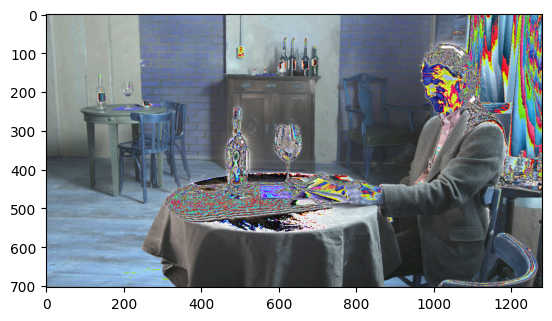

In [10]:


check_path = "/data2/saikiran.tedla/hdrvideo/diff/evaluations/stuttgart/under/bistro_01/frame_0000.png"
#load file and check % of pixels that are clipped to 0 
check_image = cv2.imread(check_path, cv2.IMREAD_UNCHANGED)
print("Shape of (check_image == 0):", (check_image == 0).shape)
num_clipped = np.sum(check_image.min(axis=2) < 1)
total_pixels = check_image.shape[0] * check_image.shape[1]
print(f"Clipped pixels: {num_clipped}, Total pixels: {total_pixels}, Percentage clipped: {num_clipped/total_pixels*100:.2f}%")

print("Show some pixel values:")
import matplotlib.pyplot as plt
plt.imshow(check_image*10)
plt.show()

